In [1]:
import gdsfactory as gf
gf.gpdk.get_generic_pdk().activate()

In [2]:
# --- Parameters (um) ---
WG_WIDTH = 0.8
PITCH = 127.0
RADIUS = (PITCH / 2) - 5.8   # U-turn Euler radius for ~127 um port spacing
GAP = 127

# Routing geometry (editable)
BEND_R = 100           # 90 deg Euler bend radius for horizontal routing
HORIZ_LEN = 2000       # horizontal section length
TOP_STRAIGHT = 4000    # straight section above horizontal (toward U-turn)
BOT_STRAIGHT = 2000    # bottom straight for first unit (facet side)
UNIT_PUSH = 100        # each unit pushes next down by this much

# Etch sweep (same combos as before)
ETCH_LENGTHS = [100, 300, 500, 800, 1500, 3000]
ETCH_WIDTHS = [10, 30, 50]
ETCH_GAPS = [0.4, 0.8, 1.5, 3]

# Layers
L_WG, L_BOX = (1, 0), (2, 0)

In [3]:
xs = gf.cross_section.strip(width=WG_WIDTH, layer=L_WG)

# Measure actual y-offset and x-offset from routing bends (for trench placement)
_rp = gf.path.euler(radius=BEND_R, angle=90)
_rp += gf.path.straight(HORIZ_LEN)
_rp += gf.path.euler(radius=BEND_R, angle=-90)
Y_TOP = float(_rp.points[-1][1])      # y of waveguide center in top section
X_ROUTING = float(_rp.points[-1][0])  # x consumed by bends + horizontal
print(f"Routing offsets: Y_TOP={Y_TOP:.1f}, X_ROUTING={X_ROUTING:.1f}")

def routed_loopback(bot_out, horiz, top_out, bend_r, loop_r, offset_y=0, bot_ret=None):
    """Loopback with horizontal routing. bot_ret offsets the return arm's
    horizontal section in x to avoid overlap with the outgoing arm.
    top_ret is auto-computed so both ports stay at x ~ 0."""
    if bot_ret is None:
        bot_ret = bot_out
    top_ret = top_out + (bot_out - bot_ret)   # keeps port o2 at x ~ 0

    p = gf.path.Path()
    # Outgoing arm
    p += gf.path.straight(bot_out)                     # bottom section (facet side)
    p += gf.path.euler(radius=bend_r, angle=90)        # bend up into horizontal
    p += gf.path.straight(horiz)                        # horizontal section
    p += gf.path.euler(radius=bend_r, angle=-90)       # bend forward toward U-turn
    p += gf.path.straight(top_out)                      # top section (trench area)
    # U-turn
    p += gf.path.euler(radius=loop_r, angle=180)
    # Return arm (asymmetric top_ret / bot_ret for horizontal spacing)
    p += gf.path.straight(top_ret)
    p += gf.path.euler(radius=bend_r, angle=90)        # bend down
    p += gf.path.straight(horiz)
    p += gf.path.euler(radius=bend_r, angle=-90)       # bend back toward facet
    p += gf.path.straight(bot_ret)
    loop = p.extrude(cross_section=xs)
    c = gf.Component()
    r = c << loop
    r.move((0, offset_y))
    c.add_port("o1", port=r.ports["o1"])
    c.add_port("o2", port=r.ports["o2"])
    return c

@gf.cell
def unit_routed(trench_l: float, trench_w: float, etch_gap: float, idx: int) -> gf.Component:
    c = gf.Component()

    # 4 bot values -- decreasing from bottom to top (25 um apart)
    b1 = BOT_STRAIGHT - idx * UNIT_PUSH      # ref outgoing
    b2 = b1 - 25                              # test outgoing
    b3 = b1 - 50                              # test return
    b4 = b1 - 75                              # ref return

    top_outer = TOP_STRAIGHT                  # 4000 (constant for all units)
    top_inner = TOP_STRAIGHT - GAP            # 3873 (constant for all units)

    # Trench placement: near test outgoing top section, 500 um before U-turn
    x_t = b2 + X_ROUTING + top_inner - 500 - trench_l
    t1 = c.add_ref(gf.components.rectangle(size=(trench_l, trench_w), layer=L_BOX))
    t2 = c.add_ref(gf.components.rectangle(size=(trench_l, trench_w), layer=L_BOX))
    t1.move((x_t, Y_TOP + WG_WIDTH / 2 + etch_gap))
    t2.move((x_t, Y_TOP - WG_WIDTH / 2 - etch_gap - trench_w))

    # Test loopback (narrow U-turn)
    c << routed_loopback(b2, HORIZ_LEN, top_inner, BEND_R, RADIUS, 0, bot_ret=b3)
    # Reference loopback (wide U-turn)
    c << routed_loopback(b1, HORIZ_LEN, top_outer, BEND_R, 3 * RADIUS, -GAP, bot_ret=b4)
    return c

Routing offsets: Y_TOP=2283.3, X_ROUTING=283.3


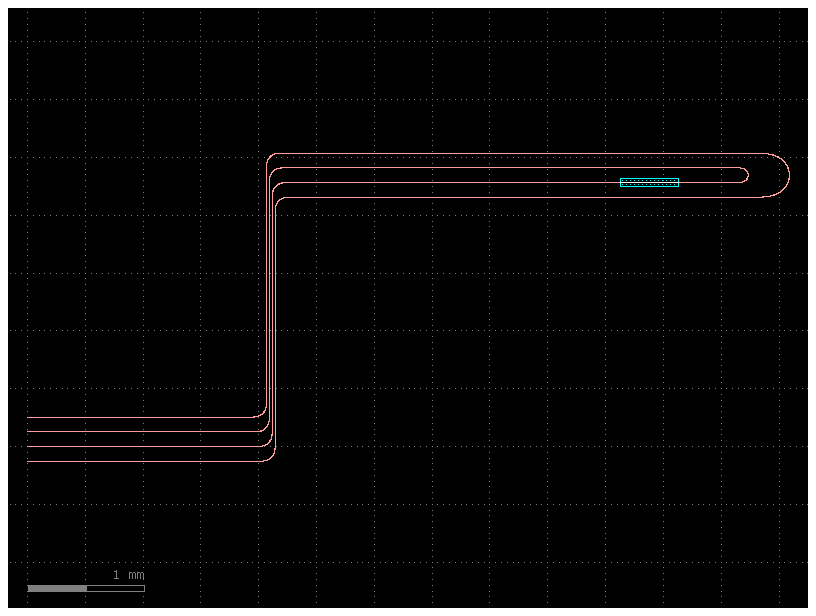

In [4]:
# Quick test: build one unit to verify geometry
test = unit_routed(500, 30, 1.5, 0)
test.plot()

Total loopback units: 20
StrainMeter: 360 shapes at x=1800, y=-8551
StrainMeter size: 608 x 175 um


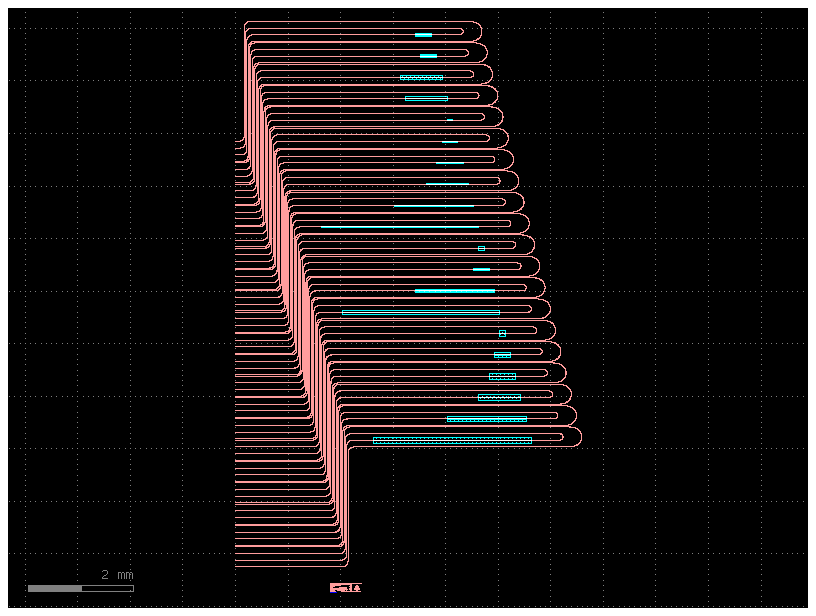

In [5]:
# Build all 20 combos (same sweep as before)
SPECIAL_LW = [(300, 30), (800, 30)]
SKIP_LW = [(500, 30), (800, 30)]

special = [(L, W, G) for L, W in SPECIAL_LW for G in [0.4, 0.8]]
sweep = []
for j, W in enumerate(ETCH_WIDTHS):
    for i, L in enumerate(ETCH_LENGTHS):
        if (L, W) in SKIP_LW:
            continue
        G = ETCH_GAPS[2] if (i + j) % 2 == 0 else ETCH_GAPS[3]
        sweep.append((L, W, G))
combos = special + sweep

# Place and label loopback units
c = gf.Component("routed_loopbacks")
LBL = (10, 0)
UNIT_SPACING = 3 * GAP + 25   # 4 ports (3x127) + 25 um inter-unit gap

for n, (L, W, G) in enumerate(combos, start=1):
    sub = c << unit_routed(L, W, G, len(combos) - n)   # bottom unit = idx 0 = longest
    sub.move((0, -UNIT_SPACING * n))
    # txt = c << gf.components.text(f"{n}: L={L} W={W} G={G}", size=20, layer=LBL)
    # txt.move((sub.x + 2200, sub.y - 150))

# ===================================================================
# Import StrainMeter.gds into corner space near bottom 90-deg bends
# ===================================================================
import klayout.db as pya

_L = pya.Layout()
_L.read("StrainMeter.gds")
_tc = _L.top_cell()
_li = _L.layer(1, 0)
_dbu = _L.dbu
_bb = _tc.bbox()

# Place in the corner space near the bottom 90-deg bends.
# Bottom unit (unit 20, idx=0) has bot=2000, placed at y=-8120.
# Its 90-deg bend is near x~2000. Place StrainMeter just below the
# bottom unit's ports, near the bend region.
strain_x = BOT_STRAIGHT - 200       # near the bottom bend area
strain_y = -UNIT_SPACING * len(combos) - 3 * GAP - 50   # below last port row

dx = strain_x - _bb.left * _dbu
dy = strain_y - _bb.top * _dbu      # align top of StrainMeter to target y

strain_comp = gf.Component("strain_meter")
n_shapes = 0
for _s in _tc.shapes(_li).each():
    if _s.is_polygon():
        pts = [(p.x * _dbu + dx, p.y * _dbu + dy) for p in _s.polygon.each_point_hull()]
        strain_comp.add_polygon(pts, layer=L_WG)
        n_shapes += 1
    elif _s.is_box():
        b = _s.box
        strain_comp.add_polygon([
            (b.left * _dbu + dx, b.bottom * _dbu + dy),
            (b.right * _dbu + dx, b.bottom * _dbu + dy),
            (b.right * _dbu + dx, b.top * _dbu + dy),
            (b.left * _dbu + dx, b.top * _dbu + dy),
        ], layer=L_WG)
        n_shapes += 1
c << strain_comp

# Label
sm_w = (_bb.right - _bb.left) * _dbu
sm_h = (_bb.top - _bb.bottom) * _dbu
stxt = c << gf.components.text("StrainMeter", size=15, layer=LBL)
stxt.move((strain_x, strain_y - sm_h - 15))

c.plot()
print(f"Total loopback units: {len(combos)}")
print(f"StrainMeter: {n_shapes} shapes at x={strain_x:.0f}, y={strain_y:.0f}")
print(f"StrainMeter size: {sm_w:.0f} x {sm_h:.0f} um")

In [6]:
c.show()
c.write_gds("routed_loopback_chip.gds")
print("Saved routed_loopback_chip.gds")

2026-05-03 18:21:15.048 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file 'C:\Users\prava\AppData\Local\Temp\2962857477.oas'
Saved routed_loopback_chip.gds


In [7]:
# Print key dimensions for reference
print(f"Top of chip (unit 1):    bot={BOT_STRAIGHT-19*UNIT_PUSH}, top={TOP_STRAIGHT}  (shortest bot)")
print(f"Bottom of chip (unit 20): bot={BOT_STRAIGHT}, top={TOP_STRAIGHT}  (longest bot)")
print(f"Top section: {TOP_STRAIGHT} constant for all units")
print(f"Unit spacing: {UNIT_SPACING} um (25 um gap between units)")
print(f"Total chip height: ~{UNIT_SPACING * 20 / 1000:.1f} mm")

Top of chip (unit 1):    bot=100, top=4000  (shortest bot)
Bottom of chip (unit 20): bot=2000, top=4000  (longest bot)
Top section: 4000 constant for all units
Unit spacing: 406 um (25 um gap between units)
Total chip height: ~8.1 mm
